Please upload your dataset file:


Saving HVDC_Dataset.csv to HVDC_Dataset.csv
Uploaded file: HVDC_Dataset.csv

DATASET OVERVIEW
Dataset Shape: (6720, 40)
Number of rows: 6720
Number of columns: 40

Column Names:
['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S', 'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5', 'Rf_Ohm', 'WindowIdx', 'Uabc_B1_pu__C1_RMS', 'Uabc_B1_pu__C2_RMS', 'Uabc_B1_pu__C3_RMS', 'Iabc_B1_pu__C1_RMS', 'Iabc_B1_pu__C2_RMS', 'Iabc_B1_pu__C3_RMS', 'P_measPref_pu__C1_RMS', 'Q_measQref_pu__C1_RMS', 'IdcPN_A__C1_RMS', 'IdcPN_A__C2_RMS', 'VdcPN_V__C1_RMS', 'VdcPN_V__C2_RMS', 'Uabc_B2_pu__C1_RMS', 'Uabc_B2_pu__C2_RMS', 'Uabc_B2_pu__C3_RMS', 'Iabc_B2_pu__C1_RMS', 'Iabc_B2_pu__C2_RMS', 'Iabc_B2_pu__C3_RMS', 'P_measPref2_pu__C1_RMS', 'Q_measQref2_pu__C1_RMS', 'IdcPN2_A__C1_RMS', 'IdcPN2_A__C2_RMS', 'VdcPN2_V__C1_RMS', 'VdcPN2_V__C2_RMS']

First 5 rows:
   No Fault  LG_R  LLG_R  LLL_R  LL_R  LG_S  LLG_S  LLL_S  LL_S  DC_L1  ...  \
0         1     0      0      0     0     0      0      0

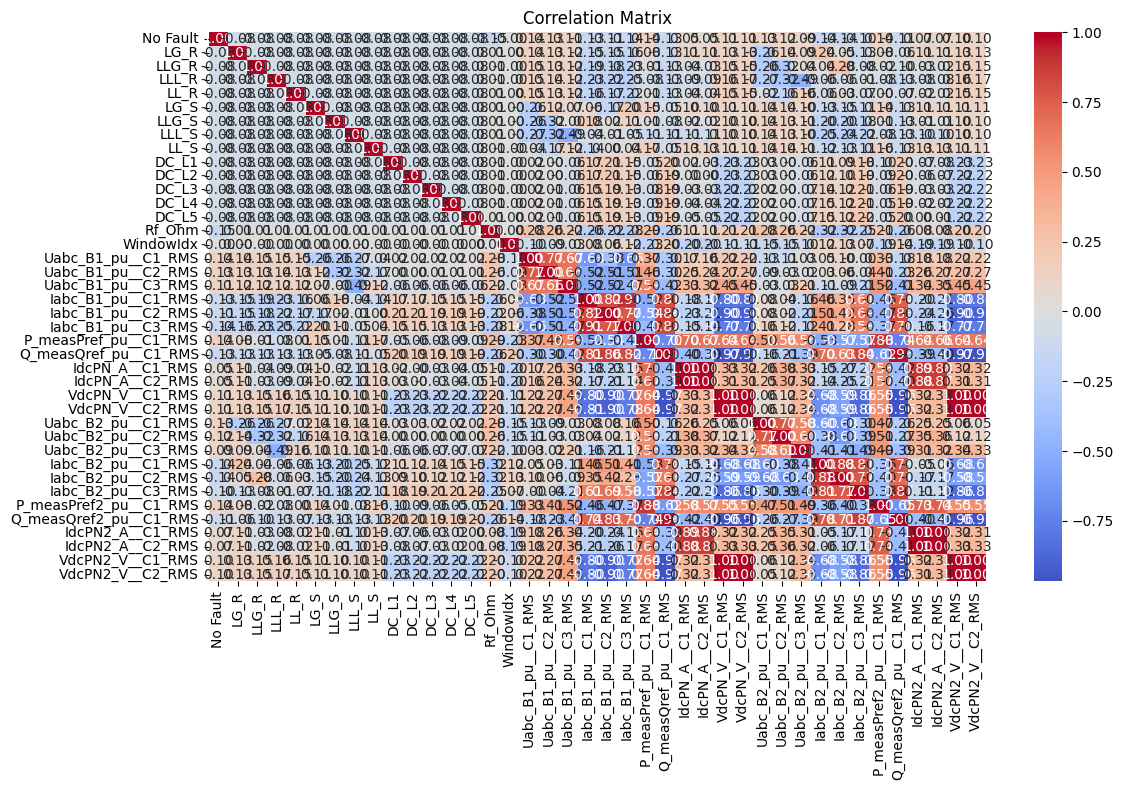


DATA VISUALIZATION


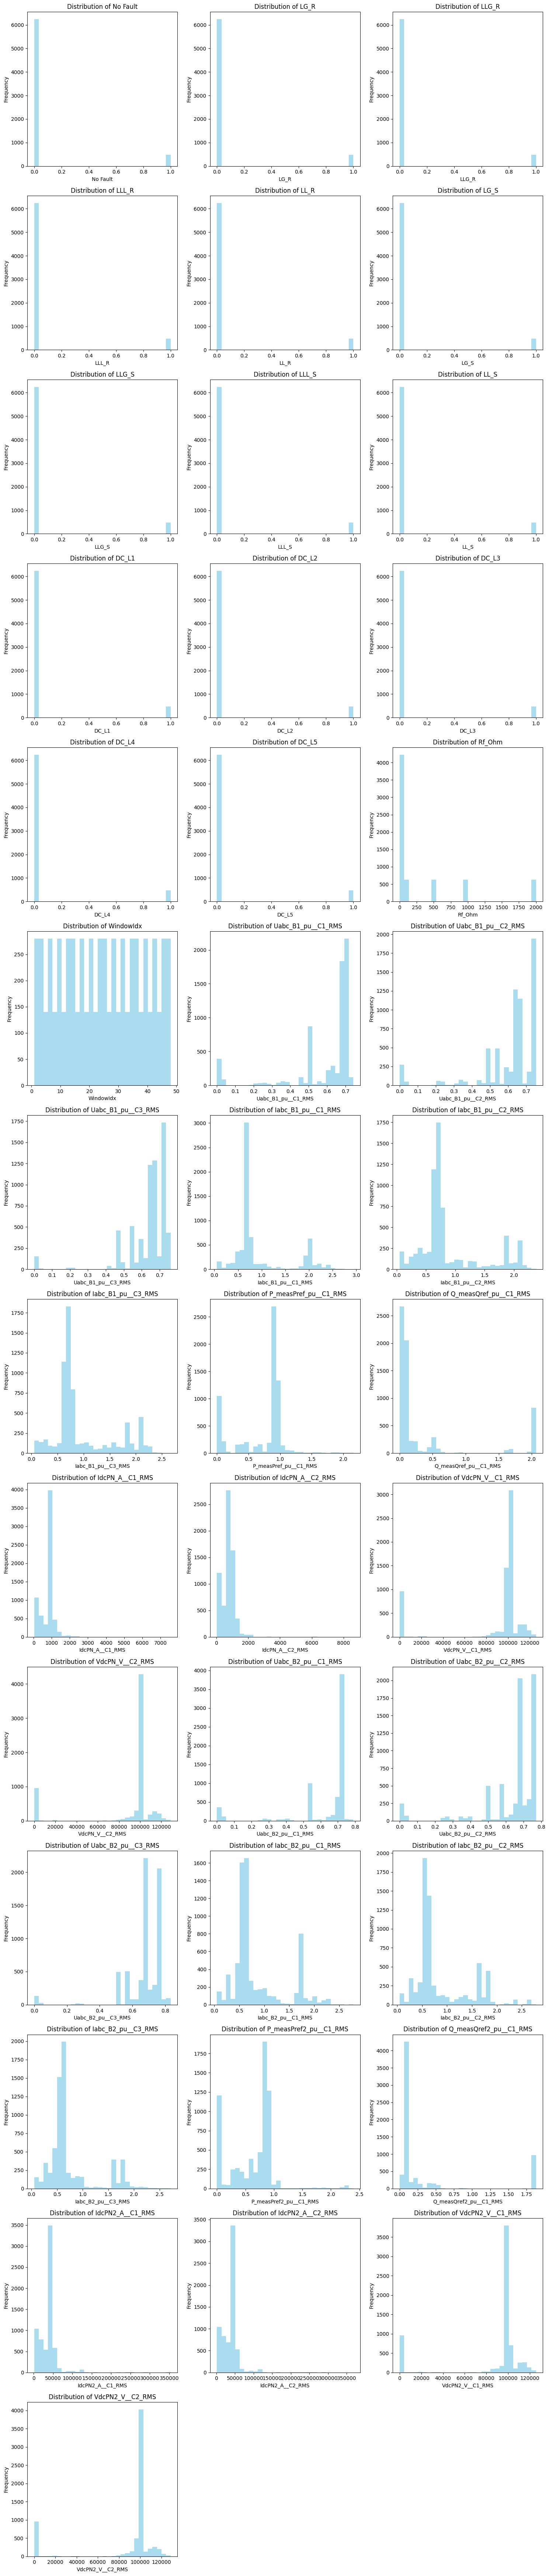


SAMPLE DATA PREVIEW
Random sample of 10 rows:
      No Fault  LG_R  LLG_R  LLL_R  LL_R  LG_S  LLG_S  LLL_S  LL_S  DC_L1  \
4460         0     0      0      0     0     0      0      0     0      1   
6148         0     0      0      0     0     0      0      0     0      0   
4569         0     0      0      0     0     0      0      0     0      1   
6412         0     0      0      0     0     0      0      0     0      0   
6379         0     0      0      0     0     0      0      0     0      0   
5911         0     0      0      0     0     0      0      0     0      0   
3105         0     0      0      0     0     0      1      0     0      0   
3146         0     0      0      0     0     0      1      0     0      0   
4672         0     0      0      0     0     0      0      0     0      1   
3528         0     0      0      0     0     0      0      1     0      0   

      ...  Uabc_B2_pu__C3_RMS  Iabc_B2_pu__C1_RMS  Iabc_B2_pu__C2_RMS  \
4460  ...            0.505659   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import os
from google.colab import files

# Upload dataset from your PC
print("Please upload your dataset file:")
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

# Function to read different types of datasets
def read_dataset(file_path):
    """
    Read dataset from various formats
    """
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        elif file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.json'):
            df = pd.read_json(file_path)
        elif file_path.endswith('.txt'):
            df = pd.read_csv(file_path, sep='\t')  # assuming tab-separated
        else:
            print("Trying to read as CSV...")
            df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

# Read the uploaded dataset
df = read_dataset(file_name)

if df is not None:
    # Basic dataset information
    print("\n" + "="*50)
    print("DATASET OVERVIEW")
    print("="*50)
    print(f"Dataset Shape: {df.shape}")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")

    print("\nColumn Names:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nLast 5 rows:")
    print(df.tail())

    print("\nDataset Info:")
    print(df.info())

    print("\nDataset Description:")
    print(df.describe())

    # Check for missing values
    print("\n" + "="*50)
    print("MISSING VALUES ANALYSIS")
    print("="*50)
    missing_values = df.isnull().sum()
    print(missing_values)

    if missing_values.sum() > 0:
        print("\nColumns with missing values:")
        print(missing_values[missing_values > 0])

    # Check data types
    print("\n" + "="*50)
    print("DATA TYPES")
    print("="*50)
    print(df.dtypes)

    # Analyze categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    if len(categorical_columns) > 0:
        print("\n" + "="*50)
        print("CATEGORICAL COLUMNS ANALYSIS")
        print("="*50)
        for col in categorical_columns:
            print(f"\nColumn: {col}")
            print(f"Unique values: {df[col].nunique()}")
            print(f"Sample values: {df[col].unique()[:10]}")  # Show first 10 unique values
            if df[col].nunique() <= 20:  # Only show all values if there are 20 or fewer
                print(f"All values: {df[col].unique()}")

    # Analyze numeric columns
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    if len(numeric_columns) > 0:
        print("\n" + "="*50)
        print("NUMERIC COLUMNS ANALYSIS")
        print("="*50)
        print(f"Numeric columns: {numeric_columns.tolist()}")
        print("\nBasic statistics for numeric columns:")
        print(df[numeric_columns].describe())

    # Try to identify target variable
    print("\n" + "="*50)
    print("TARGET VARIABLE IDENTIFICATION")
    print("="*50)
    potential_target_cols = ['target', 'label', 'class', 'y', 'output', 'prediction', df.columns[-1]]
    target_col = None

    for col in potential_target_cols:
        if col in df.columns:
            target_col = col
            break

    if target_col:
        print(f"Potential target variable: {target_col}")
        print(f"Target distribution:")
        print(df[target_col].value_counts())

        # Plot target distribution if it's categorical or has few unique values
        if df[target_col].nunique() <= 20:
            plt.figure(figsize=(10, 6))
            df[target_col].value_counts().plot(kind='bar')
            plt.title(f'Distribution of {target_col}')
            plt.xlabel(target_col)
            plt.ylabel('Count')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    else:
        print("No clear target variable identified. Please specify which column is your target.")

    # Correlation analysis for numeric data
    if len(numeric_columns) > 1:
        print("\n" + "="*50)
        print("CORRELATION ANALYSIS")
        print("="*50)
        plt.figure(figsize=(12, 8))
        correlation_matrix = df[numeric_columns].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()

    # Data visualization
    print("\n" + "="*50)
    print("DATA VISUALIZATION")
    print("="*50)

    # Plot histograms for numeric columns
    if len(numeric_columns) > 0:
        n_cols = min(3, len(numeric_columns))
        n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5*n_rows))
        if n_rows == 1:
            axes = [axes] if n_cols == 1 else axes
        else:
            axes = axes.flatten()

        for i, col in enumerate(numeric_columns):
            if i < len(axes):
                axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue')
                axes[i].set_title(f'Distribution of {col}')
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Frequency')

        # Hide empty subplots
        for i in range(len(numeric_columns), len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    # Sample data preview
    print("\n" + "="*50)
    print("SAMPLE DATA PREVIEW")
    print("="*50)
    print("Random sample of 10 rows:")
    print(df.sample(min(10, len(df))))

    print("\n" + "="*50)
    print("DATASET ANALYSIS COMPLETE")
    print("="*50)
    print("\nKey Information Summary:")
    print(f"- Dataset shape: {df.shape}")
    print(f"- Total columns: {len(df.columns)}")
    print(f"- Numeric columns: {len(numeric_columns)}")
    print(f"- Categorical columns: {len(categorical_columns)}")
    print(f"- Missing values: {df.isnull().sum().sum()}")
    if target_col:
        print(f"- Potential target variable: {target_col}")

    print("\nPlease share this output, and I'll create 3 CNN models tailored to your dataset!")

else:
    print("Failed to read the dataset. Please check the file format and try again.")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Data preprocessing
def prepare_data(df):
    # Define fault columns (targets)
    fault_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S', 'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

    # Create target labels (find which fault is active)
    y = np.argmax(df[fault_cols].values, axis=1)

    # Feature columns (excluding fault indicators, Rf_Ohm, and WindowIdx)
    feature_cols = [col for col in df.columns if col not in fault_cols + ['Rf_Ohm', 'WindowIdx']]
    X = df[feature_cols].values

    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Reshape for CNN (samples, timesteps, features)
    # We'll treat each sample as a sequence of 1 timestep with multiple features
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

    return X_reshaped, y, scaler, fault_cols

# Prepare data
X, y, scaler, fault_cols = prepare_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(fault_cols)}")
print(f"Class distribution: {np.bincount(y_train)}")

# Model 1: Simple CNN with 3 Conv1D layers
def create_cnn_model_1(input_shape, num_classes):
    model = Sequential([
        # First Conv block
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Second Conv block
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Third Conv block
        Conv1D(256, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Model 2: CNN with Residual-like connections
def create_cnn_model_2(input_shape, num_classes):
    model = Sequential([
        # First Conv block
        Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),

        # Second Conv block
        Conv1D(128, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Third Conv block
        Conv1D(256, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Dense layers
        Flatten(),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Model 3: Multi-scale CNN with different kernel sizes
def create_cnn_model_3(input_shape, num_classes):
    model = Sequential([
        # First Conv block - small kernels
        Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),

        # Second Conv block - medium kernels
        Conv1D(64, kernel_size=7, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Third Conv block - large kernels
        Conv1D(128, kernel_size=11, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train models
input_shape = (X_train.shape[1], 1)
num_classes = len(fault_cols)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Model 1
print("Training Model 1: Simple CNN")
model1 = create_cnn_model_1(input_shape, num_classes)
model1.summary()

history1 = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Model 2
print("\nTraining Model 2: CNN with Residual-like connections")
model2 = create_cnn_model_2(input_shape, num_classes)
model2.summary()

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Model 3
print("\nTraining Model 3: Multi-scale CNN")
model3 = create_cnn_model_3(input_shape, num_classes)
model3.summary()

history3 = model3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{model_name} Evaluation:")
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes, target_names=fault_cols))

    return test_accuracy

# Evaluate all models
acc1 = evaluate_model(model1, X_test, y_test, "Model 1 (Simple CNN)")
acc2 = evaluate_model(model2, X_test, y_test, "Model 2 (Residual-like CNN)")
acc3 = evaluate_model(model3, X_test, y_test, "Model 3 (Multi-scale CNN)")

# Plot training history
def plot_training_history(histories, model_names):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for history, name in zip(histories, model_names):
        ax1.plot(history.history['accuracy'], label=f'{name} Train')
        ax1.plot(history.history['val_accuracy'], label=f'{name} Val')

    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    for history, name in zip(histories, model_names):
        ax2.plot(history.history['loss'], label=f'{name} Train')
        ax2.plot(history.history['val_loss'], label=f'{name} Val')

    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history([history1, history2, history3], ['Model 1', 'Model 2', 'Model 3'])

# Best model summary
best_model_idx = np.argmax([acc1, acc2, acc3])
model_names = ['Model 1 (Simple CNN)', 'Model 2 (Residual-like CNN)', 'Model 3 (Multi-scale CNN)']
print(f"\nBest performing model: {model_names[best_model_idx]} with accuracy: {max(acc1, acc2, acc3):.4f}")

Training data shape: (5376, 24, 1)
Test data shape: (1344, 24, 1)
Number of classes: 14
Class distribution: [384 384 384 384 384 384 384 384 384 384 384 384 384 384]
Training Model 1: Simple CNN


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,894 (1.99 MB)

...

 Trainable params: 1,462,414 (5.58 MB)

 Non-trainable params: 2,944 (11.50 KB)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.1855 - loss: 3.2215 - val_accuracy: 0.0455 - val_loss: 2.6152 - learning_rate: 5.0000e-04
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3260 - loss: 2.3926 - val_accuracy: 0.0948 - val_loss: 2.6189 - learning_rate: 5.0000e-04
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.3600 - loss: 2.1485 - val_accuracy: 0.2045 - val_loss: 2.3805 - learning_rate: 5.0000e-04
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.3682 - loss: 2.0158 - val_accuracy: 0.3048 - val_loss: 2.0528 - learning_rate: 5.0000e-04
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.3815 - loss: 1.8483 - val_accuracy: 0.3866 - val_loss: 1.8063 - learning_rate: 5.0000e-04
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.4067 - loss: 1.7391 - val_accuracy: 0.4414 - val_loss: 1.5909 - learning_rate: 5.0000e-04
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ValueError: Computed output size would be negative. Received `inputs shape=(None, 8, 64)`, `kernel shape=(11, 64, 128)`, `dilation_rate=[1]`.

Training data shape: (5376, 24, 1)
Test data shape: (1344, 24, 1)
Number of features: 24
Number of classes: 14
Class distribution: [384 384 384 384 384 384 384 384 384 384 384 384 384 384]
Input shape for CNN: (24, 1)
Training Model 1: Simple CNN


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 22, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 22, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,309,326 (4.99 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 22, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 22, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 18, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 18, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 12, 128)        │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,390 (1.15 MB)

 Trainable params: 300,430 (1.15 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.2181 - loss: 2.7281 - val_accuracy: 0.2156 - val_loss: 2.4484 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3635 - loss: 1.9370 - val_accuracy: 0.2128 - val_loss: 2.4239 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3905 - loss: 1.8063 - val_accuracy: 0.3030 - val_loss: 2.0520 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4034 - loss: 1.6438 - val_accuracy: 0.3736 - val_loss: 1.7502 - learning_rate: 0.0010
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4120 - loss: 1.5907 - val_accuracy: 0.4191 - val_loss: 1.5842 - learning_rate: 0.0010
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4268 - loss: 1.5173 - val_accuracy: 0.3978 - val_loss: 1.5299 - learning_rate: 0.0010
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4447 - loss: 1.4815 - 

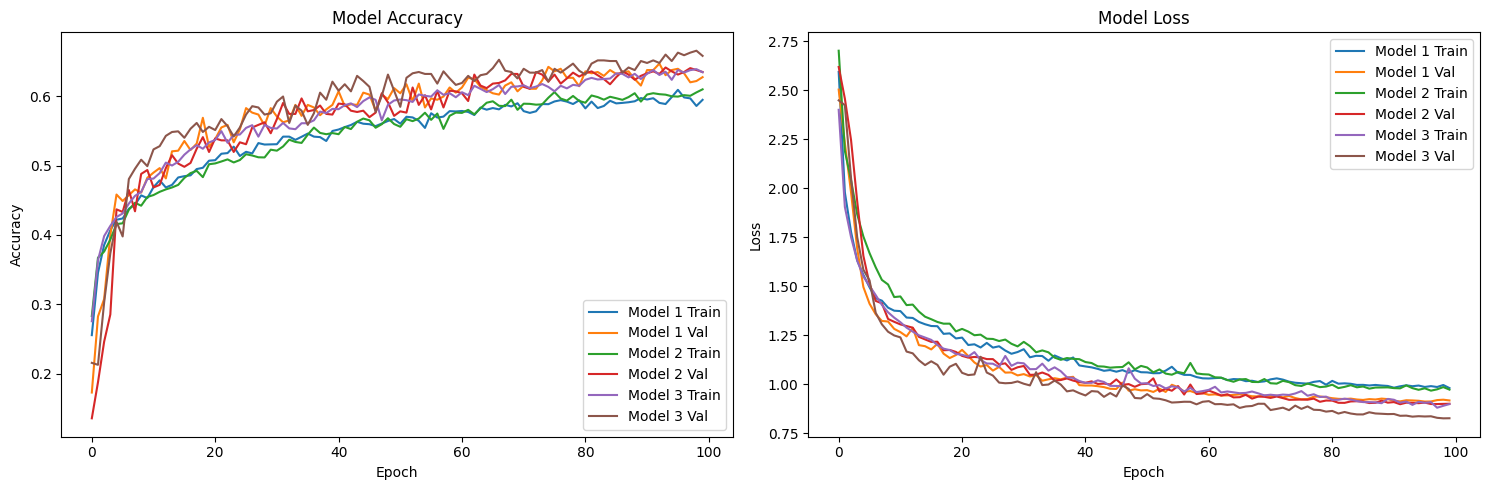


Best performing model: Model 3 (Multi-scale CNN) with accuracy: 0.6600


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Data preprocessing
def prepare_data(df):
    # Define fault columns (targets)
    fault_cols = ['No Fault', 'LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S', 'DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']

    # Create target labels (find which fault is active)
    y = np.argmax(df[fault_cols].values, axis=1)

    # Feature columns (excluding fault indicators, Rf_Ohm, and WindowIdx)
    feature_cols = [col for col in df.columns if col not in fault_cols + ['Rf_Ohm', 'WindowIdx']]
    X = df[feature_cols].values

    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Reshape for CNN (samples, timesteps, features)
    X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

    return X_reshaped, y, scaler, fault_cols, feature_cols

# Prepare data
X, y, scaler, fault_cols, feature_cols = prepare_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Number of classes: {len(fault_cols)}")
print(f"Class distribution: {np.bincount(y_train)}")

# Fixed Model 1: Simple CNN with appropriate kernel sizes
def create_cnn_model_1(input_shape, num_classes):
    model = Sequential([
        # First Conv block
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.25),

        # Second Conv block
        Conv1D(128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Third Conv block
        Conv1D(256, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Fixed Model 2: CNN with different approach
def create_cnn_model_2(input_shape, num_classes):
    model = Sequential([
        # First Conv block
        Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),

        # Second Conv block
        Conv1D(128, kernel_size=5, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Third Conv block
        Conv1D(256, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Dense layers
        Flatten(),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(512, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Fixed Model 3: Multi-scale CNN with appropriate kernel sizes
def create_cnn_model_3(input_shape, num_classes):
    model = Sequential([
        # First Conv block - small kernels
        Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),

        # Second Conv block - medium kernels
        Conv1D(64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),

        # Third Conv block - larger kernels (but appropriate size)
        Conv1D(128, kernel_size=7, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train models
input_shape = (X_train.shape[1], 1)
num_classes = len(fault_cols)

print(f"Input shape for CNN: {input_shape}")

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Model 1
print("Training Model 1: Simple CNN")
model1 = create_cnn_model_1(input_shape, num_classes)
model1.summary()

history1 = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Model 2
print("\nTraining Model 2: CNN with Different Architecture")
model2 = create_cnn_model_2(input_shape, num_classes)
model2.summary()

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Model 3
print("\nTraining Model 3: Multi-scale CNN")
model3 = create_cnn_model_3(input_shape, num_classes)
model3.summary()

history3 = model3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate models
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{model_name} Evaluation:")
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes, target_names=fault_cols))

    return test_accuracy

# Evaluate all models
acc1 = evaluate_model(model1, X_test, y_test, "Model 1 (Simple CNN)")
acc2 = evaluate_model(model2, X_test, y_test, "Model 2 (Different Architecture)")
acc3 = evaluate_model(model3, X_test, y_test, "Model 3 (Multi-scale CNN)")

# Plot training history
def plot_training_history(histories, model_names):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for history, name in zip(histories, model_names):
        ax1.plot(history.history['accuracy'], label=f'{name} Train')
        ax1.plot(history.history['val_accuracy'], label=f'{name} Val')

    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    for history, name in zip(histories, model_names):
        ax2.plot(history.history['loss'], label=f'{name} Train')
        ax2.plot(history.history['val_loss'], label=f'{name} Val')

    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history([history1, history2, history3], ['Model 1', 'Model 2', 'Model 3'])

# Best model summary
best_model_idx = np.argmax([acc1, acc2, acc3])
model_names = ['Model 1 (Simple CNN)', 'Model 2 (Different Architecture)', 'Model 3 (Multi-scale CNN)']
print(f"\nBest performing model: {model_names[best_model_idx]} with accuracy: {max(acc1, acc2, acc3):.4f}")